In [ ]:
from scripts.csv_continue_to_ds_discreet import csv_continue_to_ds_discreet
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from scripts.evaluate_model import evaluate_predictions

In [6]:
X, y = csv_continue_to_ds_discreet()

In [7]:
X

,hypertension,heart_disease,ever_married,age_low_risk,age_medium_risk,age_high_risk,glucose_low_risk,glucose_medium_risk,glucose_high_risk,bmi_low_risk,...,male,work_governative,work_private,work_self,work_never,Residence_type_Urban,smoking_status_former,smoking_status_never,smoking_status_smokes,smoking_status_unknown
0,0,1,True,False,False,True,False,False,True,False,...,True,False,True,False,False,True,True,False,False,False
1,0,0,True,False,False,True,False,True,False,False,...,False,False,False,True,False,False,False,True,False,False
2,0,1,True,False,False,True,True,False,False,False,...,True,False,True,False,False,False,False,True,False,False
3,0,0,True,False,True,False,False,True,False,False,...,False,False,True,False,False,True,False,False,True,False
4,1,0,True,False,False,True,False,True,False,True,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,1,0,True,False,False,True,True,False,False,False,...,False,False,True,False,False,True,False,True,False,False
5106,0,0,True,False,False,True,False,True,False,False,...,False,False,False,True,False,True,False,True,False,False
5107,0,0,True,True,False,False,True,False,False,False,...,False,False,False,True,False,False,False,True,False,False
5108,0,0,True,False,True,False,False,True,False,False,...,True,False,True,False,False,False,True,False,False,False


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

In [12]:
ratio = sum(y_train == 0) / sum(y_train == 1)

model_1 = Pipeline([
  ('xgboost', XGBClassifier(random_state=0, scale_pos_weight=ratio))
])

In [16]:
params = {
  'xgboost__n_estimators': [50, 100, 150],
  'xgboost__learning_rate': [0.01, 0.02, 0.05],
  'xgboost__max_depth': [5, 10]
}

cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

gs = GridSearchCV(model_1, param_grid=params, cv=cv_stratified, scoring='roc_auc', n_jobs=-1)

In [17]:
gs.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'xgboost__learning_rate': [0.01, 0.02, ...], 'xgboost__max_depth': [5, 10], 'xgboost__n_estimators': [50, 100, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [18]:
(f'best_score: {gs.best_score_}; best_params: {gs.best_params_}')

"best_score: 0.8049778266813377; best_params: {'xgboost__learning_rate': 0.02, 'xgboost__max_depth': 5, 'xgboost__n_estimators': 50}"

In [20]:
def evaluate_on_train_test(model, X_train, y_train, X_test, y_test):
    print(f"Evaluating train data")
    train_predictions = model.predict(X_train)
    train_probas = model.predict_proba(X_train)
    evaluate_predictions(train_predictions, y_train, train_probas[:, 1])
    
    print("Evaluating on test data")
    
    test_predictions = model.predict(X_test)
    test_probas = model.predict_proba(X_test)
    evaluate_predictions(test_predictions, y_test, test_probas[:, 1])


Evaluating train data


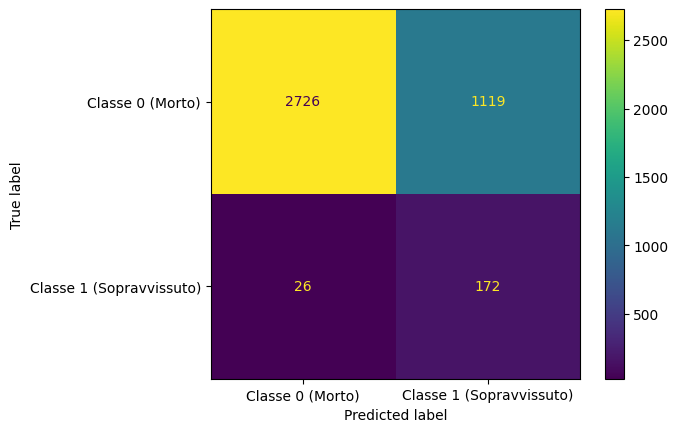

Percentuale di veri negativi: 70.90%
Percentuale di veri positivi: 86.87%
                          precision    recall  f1-score   support

        Classe 0 (Morto)       0.99      0.71      0.83      3845
Classe 1 (Sopravvissuto)       0.13      0.87      0.23       198

                accuracy                           0.72      4043
               macro avg       0.56      0.79      0.53      4043
            weighted avg       0.95      0.72      0.80      4043

[[2726 1119]
 [  26  172]]


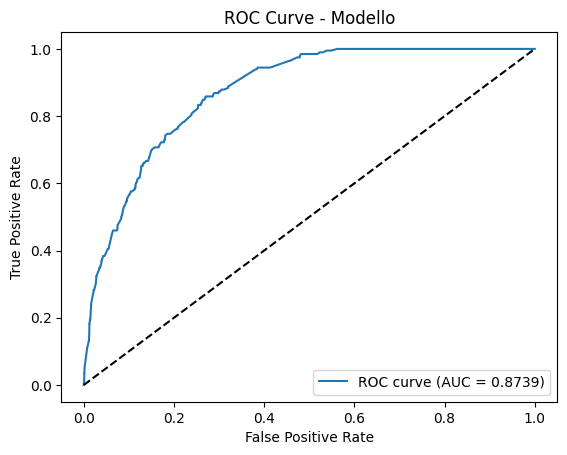

Evaluating on test data


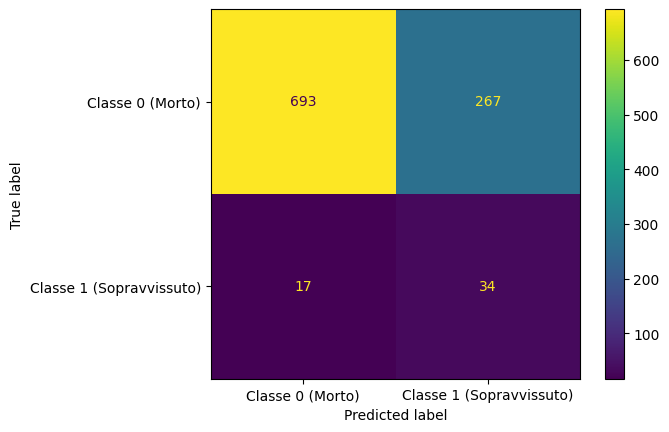

Percentuale di veri negativi: 72.19%
Percentuale di veri positivi: 66.67%
                          precision    recall  f1-score   support

        Classe 0 (Morto)       0.98      0.72      0.83       960
Classe 1 (Sopravvissuto)       0.11      0.67      0.19        51

                accuracy                           0.72      1011
               macro avg       0.54      0.69      0.51      1011
            weighted avg       0.93      0.72      0.80      1011

[[693 267]
 [ 17  34]]


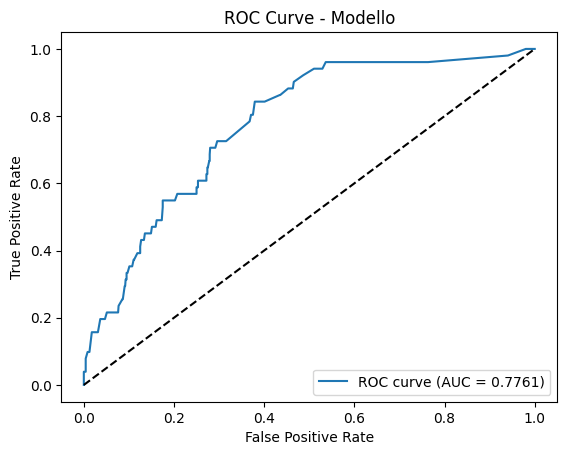

In [21]:
evaluate_on_train_test(gs.best_estimator_, X_train, y_train, X_test, y_test)